# Problem Statement

Develop an end-to-end multi-state time series forecasting system capable of predicting the next 8 weeks of sales using historical weekly sales data from 2019 to 2023.

The solution must:

- Handle missing dates and missing values
- Capture trend and seasonality patterns
- Engineer meaningful temporal forecasting features
- Train and compare multiple forecasting algorithms
- Automatically select the best-performing model for each state
- Expose predictions through REST APIs
- Provide interactive dashboard-based visualization

The forecasting system is designed to simulate a production-style machine learning pipeline for scalable business forecasting applications.

In [1]:
pip install pandas openpyxl

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd

<h3>Importing and converting excel file to our DataFrame</h3>

In [3]:
df = pd.read_excel("D:\QuickHyre AI\Forecasting Case- Study.xlsx")
df.head()

,State,Date,Total,Category
0,Alabama,2019-01-12 00:00:00,109574036.0,Beverages
1,Arizona,2019-01-12 00:00:00,109101594.6,Beverages
2,Arkansas,2019-01-12 00:00:00,58049432.2,Beverages
3,California,2019-01-12 00:00:00,444766890.6,Beverages
4,Colorado,2019-01-12 00:00:00,89816716.3,Beverages


In [4]:
df.columns

Index(['State', 'Date', 'Total', 'Category'], dtype='object')

<h4>Finding the unique set of states that are repeating themselves over Dataset.</h4>

In [5]:
df['State'].unique()

array(['Alabama', 'Arizona', 'Arkansas', 'California', 'Colorado',
       'Connecticut', 'Florida', 'Georgia', 'Illinois', 'Indiana', 'Iowa',
       'Kansas', 'Kentucky', 'Louisiana', 'Maine', 'Maryland',
       'Massachusetts', 'Michigan', 'Minnesota', 'Mississippi',
       'Missouri', 'Nebraska', 'Nevada', 'New Hampshire', 'New Mexico',
       'New York', 'North Carolina', 'Ohio', 'Oklahoma', 'Oregon',
       'Pennsylvania', 'Rhode Island', 'South Carolina', 'South Dakota',
       'Tennessee', 'Texas', 'Utah', 'Vermont', 'Virginia', 'Washington',
       'West Virginia', 'Wisconsin', 'Wyoming'], dtype=object)

<h4>Checking if there are different formats of dates being used. </h4>

In [6]:
unique_date = df['Date'].unique()
for i in unique_date:
    print(i)
    

2019-01-12 00:00:00
2019-03-11 00:00:00
2019-06-10 00:00:00
2019-08-12 00:00:00
2019-10-11 00:00:00
2020-01-03 00:00:00
2020-01-11 00:00:00
2020-02-02 00:00:00
2020-02-08 00:00:00
2020-03-05 00:00:00
2020-04-10 00:00:00
2020-05-01 00:00:00
2020-05-04 00:00:00
2020-05-07 00:00:00
2020-06-09 00:00:00
2020-06-12 00:00:00
2020-07-06 00:00:00
2020-08-03 00:00:00
2020-08-11 00:00:00
2020-09-02 00:00:00
2020-09-08 00:00:00
2020-10-05 00:00:00
2020-11-10 00:00:00
2020-12-01 00:00:00
2020-12-04 00:00:00
2020-12-07 00:00:00
2021-01-08 00:00:00
2021-02-05 00:00:00
2021-03-01 00:00:00
2021-03-10 00:00:00
2021-04-04 00:00:00
2021-04-07 00:00:00
2021-05-09 00:00:00
2021-05-12 00:00:00
2021-06-06 00:00:00
2021-07-02 00:00:00
2021-07-03 00:00:00
2021-07-11 00:00:00
2021-08-08 00:00:00
2021-09-05 00:00:00
2021-10-01 00:00:00
2021-10-10 00:00:00
2021-11-04 00:00:00
2021-11-07 00:00:00
2021-12-09 00:00:00
2021-12-12 00:00:00
2022-01-05 00:00:00
2022-02-01 00:00:00
2022-02-10 00:00:00
2022-03-04 00:00:00


<h3>STEP 1: Converting the diffrent date format to a single standardized date format, i.e. YYYY-MM-dd 00:00:00 </h3>

In [7]:
df['date'] = pd.to_datetime(
    df['Date'],
    dayfirst =True,
    errors = "coerce"
    )

In [8]:
for i in df['date'].unique():
    print(i)

2019-01-12 00:00:00
2019-03-11 00:00:00
2019-06-10 00:00:00
2019-08-12 00:00:00
2019-10-11 00:00:00
2020-01-03 00:00:00
2020-01-11 00:00:00
2020-02-02 00:00:00
2020-02-08 00:00:00
2020-03-05 00:00:00
2020-04-10 00:00:00
2020-05-01 00:00:00
2020-05-04 00:00:00
2020-05-07 00:00:00
2020-06-09 00:00:00
2020-06-12 00:00:00
2020-07-06 00:00:00
2020-08-03 00:00:00
2020-08-11 00:00:00
2020-09-02 00:00:00
2020-09-08 00:00:00
2020-10-05 00:00:00
2020-11-10 00:00:00
2020-12-01 00:00:00
2020-12-04 00:00:00
2020-12-07 00:00:00
2021-01-08 00:00:00
2021-02-05 00:00:00
2021-03-01 00:00:00
2021-03-10 00:00:00
2021-04-04 00:00:00
2021-04-07 00:00:00
2021-05-09 00:00:00
2021-05-12 00:00:00
2021-06-06 00:00:00
2021-07-02 00:00:00
2021-07-03 00:00:00
2021-07-11 00:00:00
2021-08-08 00:00:00
2021-09-05 00:00:00
2021-10-01 00:00:00
2021-10-10 00:00:00
2021-11-04 00:00:00
2021-11-07 00:00:00
2021-12-09 00:00:00
2021-12-12 00:00:00
2022-01-05 00:00:00
2022-02-01 00:00:00
2022-02-10 00:00:00
2022-03-04 00:00:00


<h4>Dropping the old Date column and checking the new set of columns</h4>

In [9]:
df = df.drop("Date", axis=1)

In [10]:
df.columns

Index(['State', 'Total', 'Category', 'date'], dtype='object')

In [11]:
df['Year'] = df['date'].dt.year

In [12]:
df.columns

Index(['State', 'Total', 'Category', 'date', 'Year'], dtype='object')

<h3>STEP 2: Sort Properly</h3>

In [13]:
df= df.sort_values(['State','date'])

In [14]:
df.head()

,State,Total,Category,date,Year
0,Alabama,109574036.0,Beverages,2019-01-12,2019
43,Alabama,112189103.8,Beverages,2019-03-11,2019
86,Alabama,129106730.4,Beverages,2019-06-10,2019
129,Alabama,108083723.8,Beverages,2019-08-12,2019
172,Alabama,110932912.8,Beverages,2019-10-11,2019


In [15]:
df['date'].dt.day_name().value_counts()

date
Sunday       5375
Friday        688
Monday        473
Tuesday       473
Saturday      430
Wednesday     344
Thursday      301
Name: count, dtype: int64

<h3>Step:3 Create Fully Weekly Timeline</h3>

In [16]:
full_dates = pd.date_range(
    start=df['date'].min(),
    end=df['date'].max(),
    freq='W-SUN'
)

In [17]:
print(full_dates)

DatetimeIndex(['2019-01-13', '2019-01-20', '2019-01-27', '2019-02-03',
               '2019-02-10', '2019-02-17', '2019-02-24', '2019-03-03',
               '2019-03-10', '2019-03-17',
               ...
               '2023-10-01', '2023-10-08', '2023-10-15', '2023-10-22',
               '2023-10-29', '2023-11-05', '2023-11-12', '2023-11-19',
               '2023-11-26', '2023-12-03'],
              dtype='datetime64[ns]', length=256, freq='W-SUN')


<h3>Step 4: Reindex Each State</h3>

In [18]:
final_dfs = []

for state in df['State'].unique():

    temp = df[df['State'] == state].copy()

    temp = temp.set_index('date')

    temp = temp.reindex(full_dates)

    temp['State'] = state

    final_dfs.append(temp)

df_final = pd.concat(final_dfs)

<h3>Restore Date Column </h3>

In [19]:
df_final = df_final.reset_index()

df_final.rename(columns={'index': 'Date'}, inplace=True)

In [20]:
df_final

,Date,State,Total,Category,Year
0,2019-01-13,Alabama,NaN,NaN,NaN
1,2019-01-20,Alabama,NaN,NaN,NaN
2,2019-01-27,Alabama,NaN,NaN,NaN
3,2019-02-03,Alabama,NaN,NaN,NaN
4,2019-02-10,Alabama,NaN,NaN,NaN
...,...,...,...,...,...
11003,2023-11-05,Wyoming,NaN,NaN,NaN
11004,2023-11-12,Wyoming,NaN,NaN,NaN
11005,2023-11-19,Wyoming,NaN,NaN,NaN
11006,2023-11-26,Wyoming,NaN,NaN,NaN


In [21]:
df_final.to_excel("df_final.xlsx", index=False)

<h3>STEP 6: Interpolate Missing Sales</h3>

In [22]:
df_final['Total'] = df_final.groupby('State')['Total']\
    .transform(lambda x: x.interpolate(method='linear'))

In [23]:
df_final.isnull().sum()

Date           0
State          0
Total       1677
Category    5633
Year        5633
dtype: int64

In [24]:
df_final.columns

Index(['Date', 'State', 'Total', 'Category', 'Year'], dtype='object')

In [25]:
df_final['Total'] = df_final.groupby('State')['Total']\
    .transform(lambda x: x.bfill().ffill())

In [26]:
df_final.isnull().sum()

Date           0
State          0
Total          0
Category    5633
Year        5633
dtype: int64

In [27]:
df_final['Category']=df_final['Category'].fillna('Beverages')

In [28]:
df_final.isnull().sum()

Date           0
State          0
Total          0
Category       0
Year        5633
dtype: int64

In [29]:
df_final=df_final.drop(['Year'],axis=1)

In [30]:
df_final.head()

,Date,State,Total,Category
0,2019-01-13,Alabama,123782285.8,Beverages
1,2019-01-20,Alabama,123782285.8,Beverages
2,2019-01-27,Alabama,123782285.8,Beverages
3,2019-02-03,Alabama,123782285.8,Beverages
4,2019-02-10,Alabama,123782285.8,Beverages


In [31]:
df_final.to_excel("Data_processed_file.xlsx", index=False)

<h2>Feature Engineering</h2>

<h3>Step1: Sort Data Properly<h3>

In [32]:
df_final=df_final.sort_values(['State','Date'])

<h3>Step2: Lag Features</h3>
<p>Lags for Weekly Data Feature Meaning<br>
lag_1	previous week<br>
lag_4	previous month<br>
lag_12	previous quarter</p>

In [33]:
df_final['lag_1'] = (
    df_final.groupby('State')['Total'].shift(1)
)

df_final['lag_4'] = (
    df_final.groupby('State')['Total'].shift(4)
)

df_final['lag_12'] = (
    df_final.groupby('State')['Total'].shift(12)
)

<h3>STEP 3: Rolling Mean & Std</h3>

Rolling Mean

In [34]:
df_final['rolling_mean_4'] = (
    df_final.groupby('State')['Total']
    .transform(lambda x: x.rolling(window=4).mean())
)

<p>Rolling Standard</p>

In [35]:
df_final['rolling_std_4'] = (
    df_final.groupby('State')['Total']
    .transform(lambda x: x.rolling(window=4).std())
)

<h3>STEP 4: Day of Week</h3>

In [36]:
df_final['day_of_week'] = df_final['Date'].dt.dayofweek

<h3>STEP 5: Month Feature</h3>

In [37]:
df_final['month'] = df_final['Date'].dt.month

<h3>STEP 6: Quarter (BONUS FEATURE)</h3>

In [38]:
df_final['quarter'] = df_final['Date'].dt.quarter

<h3>STEP 7: Week of Year (VERY GOOD FEATURE)</h3>

In [39]:
df_final['week_of_year'] = (
    df_final['Date'].dt.isocalendar().week.astype(int)
)

<h3>STEP 7.1: Year </h3>

In [40]:
df_final['year'] = df_final['Date'].dt.year

<h3>STEP 8: Holiday Flag</h3>

In [41]:
pip install holidays

Note: you may need to restart the kernel to use updated packages.


In [42]:
import holidays

us_holidays = holidays.US()

Holiday Flag Column

In [43]:
df_final['is_holiday'] = (
    df_final['Date']
    .isin(us_holidays)
    .astype(int)
)

In [44]:
df_final.head()

,Date,State,Total,Category,lag_1,lag_4,lag_12,rolling_mean_4,rolling_std_4,day_of_week,month,quarter,week_of_year,year,is_holiday
0,2019-01-13,Alabama,123782285.8,Beverages,NaN,NaN,NaN,NaN,NaN,6,1,1,2,2019,0
1,2019-01-20,Alabama,123782285.8,Beverages,123782285.8,NaN,NaN,NaN,NaN,6,1,1,3,2019,0
2,2019-01-27,Alabama,123782285.8,Beverages,123782285.8,NaN,NaN,NaN,NaN,6,1,1,4,2019,0
3,2019-02-03,Alabama,123782285.8,Beverages,123782285.8,NaN,NaN,123782285.8,0.0,6,2,1,5,2019,0
4,2019-02-10,Alabama,123782285.8,Beverages,123782285.8,123782285.8,NaN,123782285.8,0.0,6,2,1,6,2019,0


<h3>STEP 9 — Cyclical Encoding</h3>

In [45]:
import numpy as np

df_final['month_sin'] = np.sin(
    2 * np.pi * df_final['month'] / 12
)

df_final['month_cos'] = np.cos(
    2 * np.pi * df_final['month'] / 12
)

<h3>STEP 10 — Remove NaNs Generated by Lag Features</h3>

In [46]:
df_final = df_final.dropna()

## XGBoost

In [47]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [48]:
from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error
)

import pandas as pd
import numpy as np


# -----------------------------
# STORAGE
# -----------------------------
state_xgb_models = {}

state_metrics = []


# -----------------------------
# FEATURES
# -----------------------------
FEATURES = [
    'lag_1',
    'lag_4',
    'lag_12',
    'rolling_mean_4',
    'rolling_std_4',
    'day_of_week',
    'month',
    'quarter',
    'week_of_year',
    'year',
    'month_sin',
    'month_cos',
    'is_holiday'
]


# -----------------------------
# LOOP THROUGH STATES
# -----------------------------
all_states = df_final['State'].unique()

for state in all_states:

    print(f"\nTraining XGBoost for {state}...")

    state_df = df_final[
        df_final['State'] == state
    ].copy()

    state_df = state_df.sort_values(
        'Date'
    )

    # -----------------------------
    # DROP NA CREATED BY LAGS
    # -----------------------------
    state_df = state_df.dropna()

    if len(state_df) < 30:
        print(
            f"Skipping {state}"
        )
        continue

    # -----------------------------
    # SAME SPLIT AS LSTM
    # -----------------------------
    train_size = int(
        len(state_df) * 0.8
    )

    train_df = state_df.iloc[
        :train_size
    ]

    val_df = state_df.iloc[
        train_size:
    ]

    # -----------------------------
    # TRAIN DATA
    # -----------------------------
    X_train = train_df[
        FEATURES
    ]

    y_train = train_df[
        'Total'
    ]

    # -----------------------------
    # VALIDATION DATA
    # -----------------------------
    X_val = val_df[
        FEATURES
    ]

    y_val = val_df[
        'Total'
    ]

    # -----------------------------
    # MODEL
    # -----------------------------
    model = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=8,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    model.fit(
        X_train,
        y_train
    )

    preds = model.predict(
        X_val
    )

    # -----------------------------
    # METRICS
    # -----------------------------
    rmse = np.sqrt(
        mean_squared_error(
            y_val,
            preds
        )
    )

    mae = mean_absolute_error(
        y_val,
        preds
    )

    mape = (
        mean_absolute_percentage_error(
            y_val,
            preds
        ) * 100
    )

    # -----------------------------
    # STORE MODEL
    # -----------------------------
    state_xgb_models[state] = model

    # -----------------------------
    # STORE METRICS
    # -----------------------------
    state_metrics.append({
        'State': state,
        'RMSE': rmse,
        'MAE': mae,
        'MAPE': mape
    })

    print(
        f"{state} | "
        f"RMSE={rmse:,.0f} | "
        f"MAPE={mape:.2f}%"
    )


# -----------------------------
# FINAL RESULTS
# -----------------------------
xgb_metrics_df = pd.DataFrame(
    state_metrics
)

xgb_metrics_df = xgb_metrics_df.sort_values(
    by='MAPE'
)

print(xgb_metrics_df)


Training XGBoost for Alabama...
Alabama | RMSE=5,632,333 | MAPE=1.91%

Training XGBoost for Arizona...
Arizona | RMSE=13,158,427 | MAPE=5.05%

Training XGBoost for Arkansas...
Arkansas | RMSE=3,432,083 | MAPE=1.94%

Training XGBoost for California...
California | RMSE=20,285,562 | MAPE=1.89%

Training XGBoost for Colorado...
Colorado | RMSE=4,084,334 | MAPE=1.54%

Training XGBoost for Connecticut...
Connecticut | RMSE=2,754,861 | MAPE=2.57%

Training XGBoost for Florida...
Florida | RMSE=53,918,517 | MAPE=5.64%

Training XGBoost for Georgia...
Georgia | RMSE=10,116,518 | MAPE=2.03%

Training XGBoost for Illinois...
Illinois | RMSE=13,577,834 | MAPE=3.02%

Training XGBoost for Indiana...
Indiana | RMSE=6,314,770 | MAPE=1.76%

Training XGBoost for Iowa...
Iowa | RMSE=2,646,382 | MAPE=1.88%

Training XGBoost for Kansas...
Kansas | RMSE=2,608,245 | MAPE=2.44%

Training XGBoost for Kentucky...
Kentucky | RMSE=5,037,107 | MAPE=2.14%

Training XGBoost for Louisiana...
Louisiana | RMSE=10,184

<h3>Visualization</h3>

In [49]:
# import matplotlib.pyplot as plt

# plt.figure(figsize=(15,6))

# plt.plot(
#     y_val.values[:200],
#     label='Actual'
# )

# plt.plot(
#     xgb_preds[:200],
#     label='Predicted'
# )

# plt.legend()

# plt.title("XGBoost Forecast")

# plt.show()

<h2>MODEL 2: PROPHET</h2>

In [50]:
pip install prophet

Note: you may need to restart the kernel to use updated packages.


In [51]:
import pandas as pd
import numpy as np

from prophet import Prophet
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error
)


# -----------------------------
# STORAGE
# -----------------------------
state_prophet_models = {}
state_metrics = []


# -----------------------------
# LOOP THROUGH STATES
# -----------------------------
all_states = df_final['State'].unique()

for state in all_states:

    print(f"\nTraining Prophet for {state}...")

    try:
        # -----------------------------
        # FILTER STATE DATA
        # -----------------------------
        state_df = df_final[
            df_final['State'] == state
        ].copy()

        state_df = state_df.sort_values('Date')

        # -----------------------------
        # PROPHET FORMAT
        # -----------------------------
        prophet_df = state_df[['Date', 'Total']].copy()

        prophet_df.columns = ['ds', 'y']

        # -----------------------------
        # TRAIN / VALIDATION SPLIT
        # -----------------------------
        train_prophet = prophet_df[
            prophet_df['ds'] < '2023-01-01'
        ]

        val_prophet = prophet_df[
            prophet_df['ds'] >= '2023-01-01'
        ]

        if len(train_prophet) == 0 or len(val_prophet) == 0:
            print(f"Skipping {state} (insufficient split data)")
            continue

        # -----------------------------
        # MODEL
        # -----------------------------
        prophet_model = Prophet(
            yearly_seasonality=True,
            weekly_seasonality=True,
            daily_seasonality=False
        )

        prophet_model.fit(train_prophet)

        # -----------------------------
        # PREDICT
        # -----------------------------
        future = val_prophet[['ds']]

        forecast = prophet_model.predict(
            future
        )

        preds = forecast['yhat'].values
        actual = val_prophet['y'].values

        # -----------------------------
        # METRICS
        # -----------------------------
        rmse = np.sqrt(
            mean_squared_error(
                actual,
                preds
            )
        )

        mae = mean_absolute_error(
            actual,
            preds
        )

        mape = mean_absolute_percentage_error(
            actual,
            preds
        ) * 100

        # -----------------------------
        # STORE MODEL
        # -----------------------------
        state_prophet_models[state] = prophet_model

        # -----------------------------
        # STORE METRICS
        # -----------------------------
        state_metrics.append({
            'State': state,
            'RMSE': rmse,
            'MAE': mae,
            'MAPE': mape
        })

        print(
            f"{state} | "
            f"RMSE: {rmse:.2f} | "
            f"MAE: {mae:.2f} | "
            f"MAPE: {mape:.2f}%"
        )

    except Exception as e:
        print(f"Skipping {state} due to error: {e}")


# -----------------------------
# FINAL RESULTS
# -----------------------------
prophet_metrics_df = pd.DataFrame(
    state_metrics
)

prophet_metrics_df = prophet_metrics_df.sort_values(
    by='MAPE'
)

print("\nFinal Prophet Results:")
print(prophet_metrics_df)

21:01:44 - cmdstanpy - INFO - Chain [1] start processing



Training Prophet for Alabama...


21:01:45 - cmdstanpy - INFO - Chain [1] done processing
21:01:45 - cmdstanpy - INFO - Chain [1] start processing
21:01:45 - cmdstanpy - INFO - Chain [1] done processing


Alabama | RMSE: 18440341.02 | MAE: 17909786.00 | MAPE: 8.65%

Training Prophet for Arizona...


21:01:45 - cmdstanpy - INFO - Chain [1] start processing
21:01:45 - cmdstanpy - INFO - Chain [1] done processing


...

Washington | RMSE: 16352370.98 | MAE: 15668801.32 | MAPE: 8.37%

Training Prophet for West Virginia...


21:01:54 - cmdstanpy - INFO - Chain [1] start processing
21:01:54 - cmdstanpy - INFO - Chain [1] done processing


West Virginia | RMSE: 3980911.04 | MAE: 3552719.84 | MAPE: 4.84%

Training Prophet for Wisconsin...


21:01:54 - cmdstanpy - INFO - Chain [1] start processing
21:01:54 - cmdstanpy - INFO - Chain [1] done processing


Wisconsin | RMSE: 13306711.38 | MAE: 12707704.02 | MAPE: 8.08%

Training Prophet for Wyoming...
Wyoming | RMSE: 2016056.25 | MAE: 1870215.10 | MAPE: 8.67%

Final Prophet Results:
             State          RMSE           MAE       MAPE
1          Arizona  8.999913e+06  6.506720e+06   3.103491
6          Florida  3.628471e+07  3.241722e+07   4.354862
40   West Virginia  3.980911e+06  3.552720e+06   4.843046
11          Kansas  5.264593e+06  4.881823e+06   5.460447
28        Oklahoma  9.204342e+06  8.675559e+06   6.040555
10            Iowa  7.456657e+06  7.095951e+06   6.194584
24      New Mexico  5.032154e+06  4.612616e+06   6.391455
22          Nevada  6.973385e+06  6.559751e+06   6.438905
38        Virginia  2.058709e+07  1.959994e+07   6.735223
36            Utah  6.289766e+06  5.785951e+06   6.955979
3       California  6.364065e+07  6.044901e+07   7.108120
29          Oregon  8.852277e+06  8.332528e+06   7.308376
12        Kentucky  1.327831e+07  1.277241e+07   7.403050
13       

<h3>Visualisation</h3>

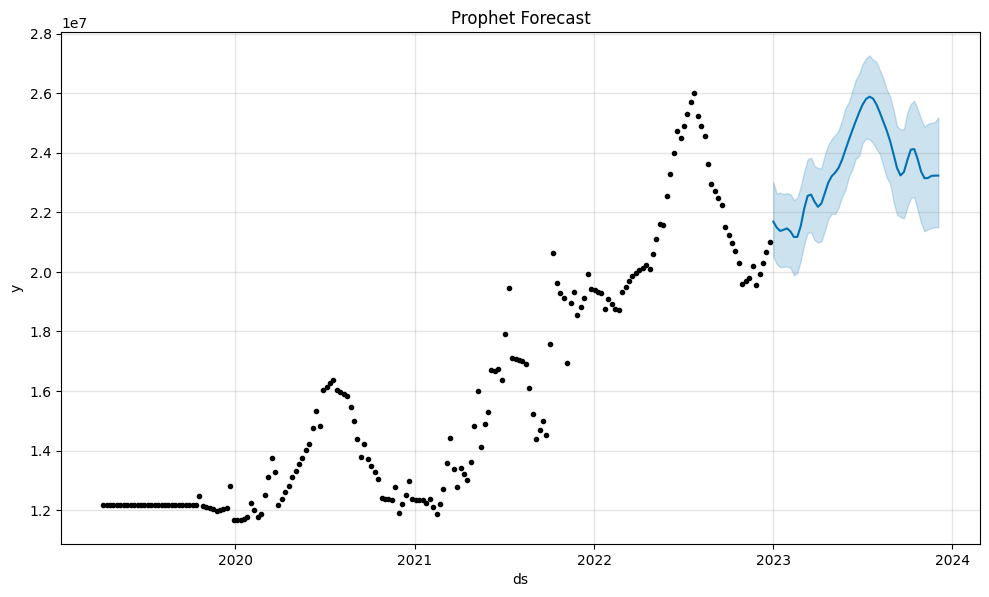

In [52]:
import matplotlib.pyplot as plt
prophet_model.plot(forecast)

plt.title("Prophet Forecast")

plt.show()

<h2>MODEL 3: ARIMA / SARIMA</h2>

In [53]:
pip install statsmodels

Note: you may need to restart the kernel to use updated packages.


<h3>STEP 1 — Prepare Series</h3>

In [54]:
for state in df_final['State'].unique():

    state_df = df_final[
        df_final['State'] == state
    ].copy()

    state_df = state_df.sort_values('Date')

# state_df = df_final[
#     df_final['State'] == 'Alabama'
# ].copy()

# state_df = state_df.sort_values('Date')

<h3>STEP 2: Split</h3>

In [55]:
train_arima = state_df[
    state_df['Date'] < '2023-01-01'
]

val_arima = state_df[
    state_df['Date'] >= '2023-01-01'
]

<h3>STEP 3: Train SARIMA</h3>

In [56]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(
    train_arima['Total'],
    order=(1,1,1),
    seasonal_order=(1,1,1,52)
)

sarima_result = sarima_model.fit()



D:\PYTHON\envs\ml\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
D:\PYTHON\envs\ml\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
D:\PYTHON\envs\ml\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


<h3>STEP 5: Evaluate</h3>

In [57]:
all_states = []
all_actuals = []
all_predictions = []
all_dates = []
all_rmse = []
all_mae = []
all_mape = []

for state in df_final['State'].unique():

    state_df = df_final[df_final['State'] == state].copy()

    train_arima = state_df[state_df['Date'] < '2023-01-01']
    val_arima = state_df[state_df['Date'] >= '2023-01-01']

    model = SARIMAX(
        train_arima['Total'],
        order=(1,1,1),
        seasonal_order=(1,1,1,52)
    )

    result = model.fit(disp=False)

    sarima_preds = result.forecast(
        steps=len(val_arima)
    )

    rmse = np.sqrt(
        mean_squared_error(
            val_arima['Total'],
            sarima_preds
        )
    )

    mae = mean_absolute_error(
        val_arima['Total'],
        sarima_preds
    )

    mape = np.mean(
    np.abs(
        (val_arima['Total'].values - sarima_preds.values)
        /
        np.where(val_arima['Total'].values == 0, 1, val_arima['Total'].values)
    )
) * 100

    all_states.extend([state] * len(val_arima))
    all_actuals.extend(val_arima['Total'].values)
    all_predictions.extend(sarima_preds.values)
    all_dates.extend(val_arima['Date'].values)

    all_rmse.extend([rmse] * len(val_arima))
    all_mae.extend([mae] * len(val_arima))
    all_mape.extend([mape] * len(val_arima))

sarima_metrics_df = pd.DataFrame({
    'Date': all_dates,
    'State': all_states,
    'Actual': all_actuals,
    'Predicted': all_predictions,
    'RMSE': all_rmse,
    'MAE': all_mae,
    'MAPE': all_mape
})

D:\PYTHON\envs\ml\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
D:\PYTHON\envs\ml\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
D:\PYTHON\envs\ml\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
D:\PYTHON\envs\ml\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with

In [58]:
sarima_metrics_summary = (sarima_metrics_df.groupby('State')[['RMSE','MAE','MAPE']].first().reset_index())
print(sarima_metrics_summary)



             State          RMSE           MAE       MAPE
0          Alabama  2.225089e+07  2.096857e+07   9.986616
1          Arizona  1.335530e+07  1.241915e+07   5.570365
2         Arkansas  1.180628e+07  1.123439e+07  10.118556
3       California  7.292431e+07  6.785866e+07   7.813272
4         Colorado  1.913141e+07  1.788605e+07  10.116626
5      Connecticut  1.161119e+07  1.096863e+07  12.257110
6          Florida  3.570170e+07  3.046508e+07   3.999853
7          Georgia  4.227702e+07  4.041263e+07  10.319129
8         Illinois  3.019131e+07  2.829819e+07   8.836611
9          Indiana  2.678434e+07  2.571857e+07  11.416204
10            Iowa  1.036835e+07  9.659011e+06   8.257540
11          Kansas  8.852229e+06  8.385636e+06   9.198901
12        Kentucky  1.755935e+07  1.673104e+07   9.535732
13       Louisiana  1.482725e+07  1.353036e+07   7.440023
14           Maine  8.071662e+06  7.267476e+06  15.315518
15        Maryland  1.880464e+07  1.747347e+07  10.635974
16   Massachus

<h2>MODEL 4: LSTM</h2>

In [59]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense


# -----------------------------
# CONFIG
# -----------------------------
SEQ_LENGTH = 12
EPOCHS = 20
BATCH_SIZE = 16


# -----------------------------
# STORAGE
# -----------------------------
state_lstm_models = {}
state_metrics = []


# -----------------------------
# SEQUENCE FUNCTION
# -----------------------------
def create_sequences(data, seq_length=12):

    X = []
    y = []

    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])
        y.append(data[i + seq_length])

    return np.array(X), np.array(y)


# -----------------------------
# LOOP OVER STATES
# -----------------------------
all_states = df_final['State'].unique()

for state in all_states:

    print(f"\nTraining LSTM for {state}...")

    # -----------------------------
    # FILTER STATE DATA
    # -----------------------------
    state_df = df_final[
        df_final['State'] == state
    ].copy()

    state_df = state_df.sort_values('Date')

    raw_data = state_df[['Total']].values

    # Skip very small states
    if len(raw_data) <= SEQ_LENGTH + 10:
        print(f"Skipping {state} (not enough data)")
        continue

    # -----------------------------
    # TRAIN / VALIDATION SPLIT
    # -----------------------------
    train_size = int(len(raw_data) * 0.8)

    train_raw = raw_data[:train_size]
    val_raw = raw_data[train_size:]

    # -----------------------------
    # SCALING (NO LEAKAGE)
    # -----------------------------
    scaler = MinMaxScaler()

    train_scaled = scaler.fit_transform(train_raw)

    val_scaled = scaler.transform(val_raw)

    # -----------------------------
    # TRAIN SEQUENCES
    # -----------------------------
    X_train, y_train = create_sequences(
        train_scaled,
        seq_length=SEQ_LENGTH
    )

    # -----------------------------
    # VALIDATION SEQUENCES
    # -----------------------------
    combined_for_val = np.concatenate(
        [train_scaled[-SEQ_LENGTH:], val_scaled],
        axis=0
    )

    X_val, y_val = create_sequences(
        combined_for_val,
        seq_length=SEQ_LENGTH
    )

    # Safety check
    if len(X_train) == 0 or len(X_val) == 0:
        print(f"Skipping {state} (sequence issue)")
        continue

    # -----------------------------
    # MODEL
    # -----------------------------
    model = Sequential([
        LSTM(
            64,
            input_shape=(SEQ_LENGTH, 1)
        ),
        Dense(1)
    ])

    model.compile(
        optimizer='adam',
        loss='mse'
    )

    # -----------------------------
    # TRAIN
    # -----------------------------
    model.fit(
        X_train,
        y_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_data=(X_val, y_val),
        verbose=0
    )

    # -----------------------------
    # PREDICT
    # -----------------------------
    preds_scaled = model.predict(
        X_val,
        verbose=0
    )

    preds = scaler.inverse_transform(
        preds_scaled
    )

    actuals = scaler.inverse_transform(
        y_val.reshape(-1, 1)
    )

    # -----------------------------
    # METRICS
    # -----------------------------
    rmse = np.sqrt(
        mean_squared_error(
            actuals,
            preds
        )
    )

    mae = mean_absolute_error(
        actuals,
        preds
    )

    mape = np.mean(
    np.abs(
        (actuals - preds) / actuals
    )
) * 100

    # -----------------------------
    # STORE
    # -----------------------------
    state_lstm_models[state] = {
        'model': model,
        'scaler': scaler
    }

    state_metrics.append({
        'State': state,
        'RMSE': rmse,
        'MAE': mae,
    'MAPE': mape
    })

    print(f"{state} RMSE: {rmse:.2f}")


# -----------------------------
# METRICS DATAFRAME
# -----------------------------
metrics_df = pd.DataFrame(
    state_metrics
)

metrics_df = metrics_df.sort_values(
    by='RMSE'
)

print("\nFinal Results:")
print(metrics_df)


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "D:\PYTHON\envs\ml\lib\runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "D:\PYTHON\envs\ml\lib\runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "D:\PYTHON\envs\ml\lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "D:\PYTHON\envs\ml\lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "D:\PYTHON\envs\ml\lib\site-packages\ipykernel\kernelapp.py", line

AttributeError: _ARRAY_API not found


Training LSTM for Alabama...


D:\PYTHON\envs\ml\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Alabama RMSE: 6297008.88

Training LSTM for Arizona...


...

West Virginia RMSE: 1917810.20

Training LSTM for Wisconsin...


D:\PYTHON\envs\ml\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Wisconsin RMSE: 4188038.86

Training LSTM for Wyoming...


D:\PYTHON\envs\ml\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Wyoming RMSE: 534771.61

Final Results:
             State          RMSE           MAE      MAPE
37         Vermont  4.389936e+05  3.336881e+05  1.862989
42         Wyoming  5.347716e+05  4.145078e+05  1.927410
33    South Dakota  6.600586e+05  4.120249e+05  1.471477
31    Rhode Island  7.745159e+05  5.533209e+05  2.164819
14           Maine  9.423221e+05  5.184071e+05  1.139170
23   New Hampshire  1.274380e+06  8.719510e+05  1.601077
40   West Virginia  1.917810e+06  1.241308e+06  1.731986
21        Nebraska  1.930937e+06  1.329863e+06  2.190908
24      New Mexico  2.458565e+06  2.020223e+06  2.783752
22          Nevada  2.567136e+06  1.823718e+06  1.811451
36            Utah  2.590737e+06  1.547725e+06  1.929761
5      Connecticut  2.667418e+06  1.414989e+06  1.685716
11          Kansas  2.758311e+06  1.976204e+06  2.227950
28        Oklahoma  2.988991e+06  1.890124e+06  1.342197
2         Arkansas  3.155418e+06  2.157933e+06  2.024382
29          Oregon  3.249298e+06  2.036789e+06  

<h3>Visualization</h3>

In [60]:
# plt.figure(figsize=(15,6))

# plt.plot(
#     y_val_actual,
#     label='Actual',
#     linewidth=2
# )

# plt.plot(
#     lstm_preds,
#     label='LSTM Prediction',
#     linewidth=2
# )

# plt.title('LSTM Forecast vs Actual')

# plt.xlabel('Time')

# plt.ylabel('Sales')

# plt.legend()

# plt.grid(True)

# plt.show()

In [61]:
import pandas as pd


# -----------------------------
# RENAME COLUMNS
# -----------------------------
lstm_df = metrics_df.rename(columns={
    'RMSE': 'LSTM_RMSE',
    'MAE': 'LSTM_MAE',
    'MAPE': 'LSTM_MAPE'
})

xgb_df = xgb_metrics_df.rename(columns={
    'RMSE': 'XGB_RMSE',
    'MAE': 'XGB_MAE',
    'MAPE': 'XGB_MAPE'
})

sarima_df = sarima_metrics_df.rename(columns={
    'RMSE': 'SARIMA_RMSE',
    'MAE': 'SARIMA_MAE',
    'MAPE': 'SARIMA_MAPE'
})

prophet_df = prophet_metrics_df.rename(columns={
    'RMSE': 'PROPHET_RMSE',
    'MAE': 'PROPHET_MAE',
    'MAPE': 'PROPHET_MAPE'
})


# -----------------------------
# MERGE ALL RESULTS
# -----------------------------
final_comparison_df = lstm_df.merge(
    xgb_df,
    on='State',
    how='outer'
)

final_comparison_df = final_comparison_df.merge(
    sarima_df,
    on='State',
    how='outer'
)

final_comparison_df = final_comparison_df.merge(
    prophet_df,
    on='State',
    how='outer'
)


# -----------------------------
# PICK BEST MODEL USING MAPE
# -----------------------------
mape_columns = [
    'LSTM_MAPE',
    'XGB_MAPE',
    'SARIMA_MAPE',
    'PROPHET_MAPE'
]

final_comparison_df['Best_Model'] = (
    final_comparison_df[mape_columns]
    .idxmin(axis=1)
    .str.replace('_MAPE', '')
)


# -----------------------------
# BEST MODEL MAPE
# -----------------------------
final_comparison_df['Best_MAPE'] = (
    final_comparison_df[mape_columns]
    .min(axis=1)
)


# -----------------------------
# SORT
# -----------------------------
final_comparison_df = final_comparison_df.sort_values(
    by='Best_MAPE'
)


# -----------------------------
# FINAL OUTPUT
# -----------------------------
print(final_comparison_df)

       State     LSTM_RMSE      LSTM_MAE  LSTM_MAPE      XGB_RMSE  \
733    Maine  9.423221e+05  5.184071e+05   1.139170  1.510522e+06   
734    Maine  9.423221e+05  5.184071e+05   1.139170  1.510522e+06   
706    Maine  9.423221e+05  5.184071e+05   1.139170  1.510522e+06   
705    Maine  9.423221e+05  5.184071e+05   1.139170  1.510522e+06   
707    Maine  9.423221e+05  5.184071e+05   1.139170  1.510522e+06   
..       ...           ...           ...        ...           ...   
80   Arizona  9.316750e+06  7.833425e+06   3.507238  1.315843e+07   
51   Arizona  9.316750e+06  7.833425e+06   3.507238  1.315843e+07   
49   Arizona  9.316750e+06  7.833425e+06   3.507238  1.315843e+07   
50   Arizona  9.316750e+06  7.833425e+06   3.507238  1.315843e+07   
52   Arizona  9.316750e+06  7.833425e+06   3.507238  1.315843e+07   

          XGB_MAE  XGB_MAPE       Date        Actual     Predicted  \
733  1.074906e+06  2.321158 2023-11-26  4.885079e+07  5.437654e+07   
734  1.074906e+06  2.321158 202

In [62]:
best_model_registry = dict(
    zip(
        final_comparison_df['State'],
        final_comparison_df['Best_Model']
    )
)

print(best_model_registry)

{'Maine': 'LSTM', 'Mississippi': 'XGB', 'Oklahoma': 'LSTM', 'Colorado': 'LSTM', 'Texas': 'LSTM', 'Wyoming': 'XGB', 'South Dakota': 'LSTM', 'Washington': 'LSTM', 'North Carolina': 'LSTM', 'New Hampshire': 'LSTM', 'Minnesota': 'LSTM', 'Florida': 'LSTM', 'Connecticut': 'LSTM', 'Missouri': 'XGB', 'West Virginia': 'LSTM', 'Indiana': 'XGB', 'Nevada': 'LSTM', 'California': 'LSTM', 'Oregon': 'LSTM', 'Nebraska': 'XGB', 'Utah': 'XGB', 'Tennessee': 'XGB', 'Vermont': 'LSTM', 'New York': 'LSTM', 'Iowa': 'XGB', 'Ohio': 'LSTM', 'Wisconsin': 'LSTM', 'Massachusetts': 'LSTM', 'Alabama': 'XGB', 'Maryland': 'XGB', 'Arkansas': 'XGB', 'New Mexico': 'XGB', 'Pennsylvania': 'LSTM', 'South Carolina': 'XGB', 'Michigan': 'XGB', 'Georgia': 'XGB', 'Louisiana': 'LSTM', 'Kentucky': 'LSTM', 'Rhode Island': 'LSTM', 'Kansas': 'LSTM', 'Virginia': 'XGB', 'Illinois': 'XGB', 'Arizona': 'PROPHET'}


In [63]:
metrics_registry = {}

for _, row in final_comparison_df.iterrows():

    state = row['State']

    metrics_df_state = pd.DataFrame({
        'Model': ['XGB', 'LSTM', 'SARIMA', 'PROPHET'],
        'RMSE': [
            row['XGB_RMSE'],
            row['LSTM_RMSE'],
            row['SARIMA_RMSE'],
            row['PROPHET_RMSE']
        ],
        'MAE': [
            row['XGB_MAE'],
            row['LSTM_MAE'],
            row['SARIMA_MAE'],
            row['PROPHET_MAE']
        ],
        'MAPE': [
            row['XGB_MAPE'],
            row['LSTM_MAPE'],
            row['SARIMA_MAPE'],
            row['PROPHET_MAPE']
        ]
    })

    metrics_registry[state] = metrics_df_state

In [66]:
print(metrics_df.shape)
print(xgb_metrics_df.shape)
print(prophet_metrics_df.shape)
print(sarima_metrics_summary.shape)

(43, 4)
(43, 4)
(43, 4)
(43, 4)


<h2>Combined Forcast Comparision</h2>

In [67]:
import os
import json
import joblib

from prophet.serialize import model_to_json

os.makedirs("models", exist_ok=True)

# ----------------------------------
# SAVE REGISTRIES
# ----------------------------------

with open(
    "models/best_model_registry.json",
    "w"
) as f:

    json.dump(
        best_model_registry,
        f
    )

joblib.dump(
    best_model_registry,
    "best_model_registry.pkl"
)

joblib.dump(
    metrics_registry,
    "metrics_registry.pkl"
)


# ----------------------------------
# SAVE LSTM WINNERS
# ----------------------------------

lstm_states = [
    state for state,model in best_model_registry.items() if model=='LSTM'
]

for state in lstm_states:

    safe_name = (
        state.lower()
        .replace(" ", "_")
    )

    state_lstm_models[state]['model'].save(
        f"models/{safe_name}_lstm.keras"
    )

    joblib.dump(
        state_lstm_models[state]['scaler'],
        f"models/{safe_name}_scaler.pkl"
    )


# ----------------------------------
# SAVE XGB WINNERS
# ----------------------------------

xgb_states = [
    state for state,model in best_model_registry.items() if model=='XGB'
]
for state in xgb_states:

    safe_name = (
        state.lower()
        .replace(" ", "_")
    )

    joblib.dump(
        state_xgb_models[state],
        f"models/{safe_name}_xgb.pkl"
    )


# ----------------------------------
# SAVE PROPHET WINNER
# ----------------------------------

with open(
    "models/arizona_prophet.json",
    "w"
) as fout:

    fout.write(
        model_to_json(
            state_prophet_models['Arizona']
        )
    )

print("All winning models saved successfully.")

All winning models saved successfully.


In [68]:
joblib.dump(
    metrics_registry,
    "metrics_registry.pkl"
)

['metrics_registry.pkl']

In [72]:
state_lstm_models['Texas']

{'model': <Sequential name=sequential_35, built=True>,
 'scaler': MinMaxScaler()}

In [73]:
print(state_lstm_models.keys())

dict_keys(['Alabama', 'Arizona', 'Arkansas', 'California', 'Colorado', 'Connecticut', 'Florida', 'Georgia', 'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana', 'Maine', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota', 'Mississippi', 'Missouri', 'Nebraska', 'Nevada', 'New Hampshire', 'New Mexico', 'New York', 'North Carolina', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania', 'Rhode Island', 'South Carolina', 'South Dakota', 'Tennessee', 'Texas', 'Utah', 'Vermont', 'Virginia', 'Washington', 'West Virginia', 'Wisconsin', 'Wyoming'])


In [74]:
print(type(state_xgb_models))
print(list(state_xgb_models.keys())[:5])

<class 'dict'>
['Alabama', 'Arizona', 'Arkansas', 'California', 'Colorado']


In [75]:
import os

print(len(os.listdir("models")))

69


In [76]:
print(sorted(os.listdir("models"))[:20])

['alabama_xgb.pkl', 'arizona_prophet.json', 'arkansas_xgb.pkl', 'best_model_registry.json', 'california_lstm.keras', 'california_scaler.pkl', 'colorado_lstm.keras', 'colorado_scaler.pkl', 'connecticut_lstm.keras', 'connecticut_scaler.pkl', 'florida_lstm.keras', 'florida_scaler.pkl', 'georgia_xgb.pkl', 'illinois_xgb.pkl', 'indiana_xgb.pkl', 'iowa_xgb.pkl', 'kansas_lstm.keras', 'kansas_scaler.pkl', 'kentucky_lstm.keras', 'kentucky_scaler.pkl']


In [77]:
print(df_final.columns.tolist())

['Date', 'State', 'Total', 'Category', 'lag_1', 'lag_4', 'lag_12', 'rolling_mean_4', 'rolling_std_4', 'day_of_week', 'month', 'quarter', 'week_of_year', 'year', 'is_holiday', 'month_sin', 'month_cos']


In [78]:
print(df_final.shape)

print(df_final[['Date','State','Total']].tail())

(10492, 17)
            Date    State       Total
11003 2023-11-05  Wyoming  22026898.1
11004 2023-11-12  Wyoming  22008939.8
11005 2023-11-19  Wyoming  21990981.5
11006 2023-11-26  Wyoming  21973023.2
11007 2023-12-03  Wyoming  21955064.9


In [79]:
df_final.isna().sum()

Date              0
State             0
Total             0
Category          0
lag_1             0
lag_4             0
lag_12            0
rolling_mean_4    0
rolling_std_4     0
day_of_week       0
month             0
quarter           0
week_of_year      0
year              0
is_holiday        0
month_sin         0
month_cos         0
dtype: int64

In [80]:
print(df_final.columns)

Index(['Date', 'State', 'Total', 'Category', 'lag_1', 'lag_4', 'lag_12',
       'rolling_mean_4', 'rolling_std_4', 'day_of_week', 'month', 'quarter',
       'week_of_year', 'year', 'is_holiday', 'month_sin', 'month_cos'],
      dtype='object')


In [81]:
print(type(state_prophet_models))
print(state_prophet_models.keys())


<class 'dict'>
dict_keys(['Alabama', 'Arizona', 'Arkansas', 'California', 'Colorado', 'Connecticut', 'Florida', 'Georgia', 'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana', 'Maine', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota', 'Mississippi', 'Missouri', 'Nebraska', 'Nevada', 'New Hampshire', 'New Mexico', 'New York', 'North Carolina', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania', 'Rhode Island', 'South Carolina', 'South Dakota', 'Tennessee', 'Texas', 'Utah', 'Vermont', 'Virginia', 'Washington', 'West Virginia', 'Wisconsin', 'Wyoming'])


In [82]:
print(type(metrics_registry))
print(metrics_registry.keys())
print(metrics_registry['Texas'])


<class 'dict'>
dict_keys(['Maine', 'Mississippi', 'Oklahoma', 'Colorado', 'Texas', 'Wyoming', 'South Dakota', 'Washington', 'North Carolina', 'New Hampshire', 'Minnesota', 'Florida', 'Connecticut', 'Missouri', 'West Virginia', 'Indiana', 'Nevada', 'California', 'Oregon', 'Nebraska', 'Utah', 'Tennessee', 'Vermont', 'New York', 'Iowa', 'Ohio', 'Wisconsin', 'Massachusetts', 'Alabama', 'Maryland', 'Arkansas', 'New Mexico', 'Pennsylvania', 'South Carolina', 'Michigan', 'Georgia', 'Louisiana', 'Kentucky', 'Rhode Island', 'Kansas', 'Virginia', 'Illinois', 'Arizona'])
     Model          RMSE           MAE       MAPE
0      XGB  2.293477e+07  1.649319e+07   1.869986
1     LSTM  2.230496e+07  1.203628e+07   1.411336
2   SARIMA  9.702461e+07  9.074484e+07   9.891150
3  PROPHET  9.955172e+07  9.765768e+07  10.756433
